In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt


d:\GP\Scimilarity_test\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\colon_merged.h5ad")
print(adata_1)


AnnData object with n_obs × n_vars = 32636 × 12502
    obs: 'cell_type', 'species', 'assay'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'


In [3]:
adata_1.var.head()

""
TSPAN6
DPM1
SCYL3
FGR
CFH


In [4]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [5]:
adata_1.layers["counts"] = adata_1.X.copy()


In [6]:
from scimilarity.utils import align_dataset, lognorm_counts
adata_1 = align_dataset(adata_1, ce.gene_order)
adata_1 = lognorm_counts(adata_1)

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):
  
    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values
        
        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

In [8]:

X = adata_1.X
embeddings= ce.get_embeddings(X)
adata_1.obsm["X_emb"] = embeddings

In [9]:
print(embeddings.shape)
# save combined embeddings to project directory
adata_1.write_h5ad(r"D:\GP\Notebooks\Scimilarity\Colon_combined_Monkey+Human_embeddings.h5ad")


(32636, 128)


In [10]:
import scanpy as sc

In [11]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Colon_combined_Monkey+Human_embeddings.h5ad")
print(adata_1)

AnnData object with n_obs × n_vars = 32636 × 28231
    obs: 'cell_type', 'species', 'assay'
    uns: 'orig_genes'
    obsm: 'X_emb', 'X_pca', 'X_umap'
    layers: 'counts'


In [13]:
label_keys = ["cell_type","species"]
# Compute scores
scores = compute_silhouette_and_lisi_avg(adata_1, label_keys, embed_key="X_emb", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': 0.4973520338535309, 'species': 0.0709916427731514}
LISI Scores: {'cell_type': 1.0146194254850518, 'species': 1.011110439186547}


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [15]:
import matplotlib.pyplot as plt

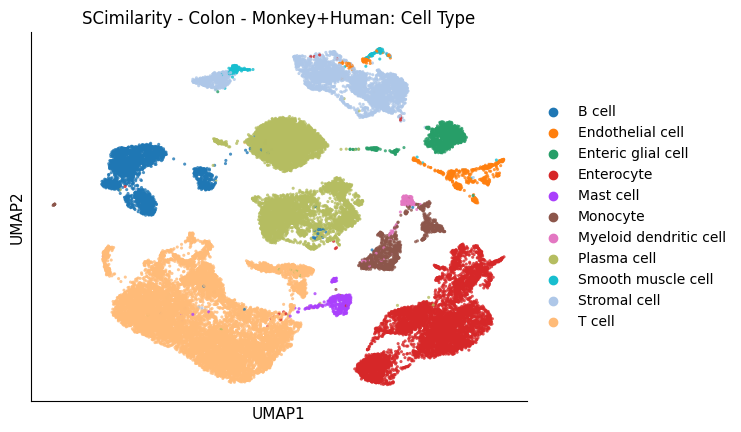

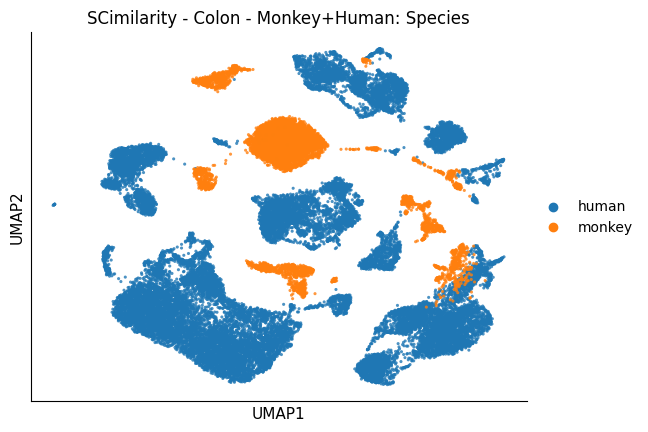

=== Logistic Regression ===
Accuracy: 0.9470077661032434
                        precision    recall  f1-score   support

                B cell       0.98      0.95      0.97       326
      Endothelial cell       1.00      0.81      0.89       275
    Enteric glial cell       1.00      0.89      0.94        70
            Enterocyte       0.88      1.00      0.94       405
             Mast cell       1.00      1.00      1.00        49
              Monocyte       0.86      0.96      0.91       334
Myeloid dendritic cell       1.00      0.12      0.21       137
           Plasma cell       0.99      1.00      0.99      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.76      1.00      0.86       407
                T cell       0.99      0.99      0.99       740

              accuracy                           0.95      6567
             macro avg       0.86      0.79      0.79      6567
          weighted avg       0.94      0.95  

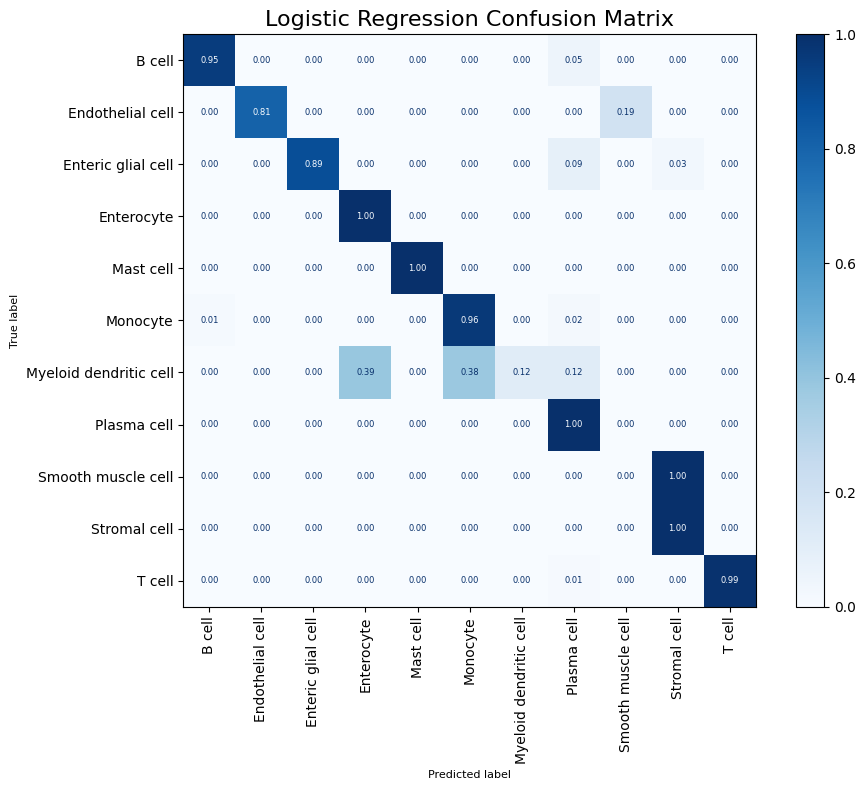


=== k-NN ===
Accuracy: 0.9401553220648698
                        precision    recall  f1-score   support

                B cell       1.00      0.95      0.97       326
      Endothelial cell       1.00      0.73      0.85       275
    Enteric glial cell       0.97      0.93      0.95        70
            Enterocyte       0.99      1.00      0.99       405
             Mast cell       1.00      1.00      1.00        49
              Monocyte       0.70      0.92      0.79       334
Myeloid dendritic cell       0.19      0.04      0.07       137
           Plasma cell       0.99      1.00      1.00      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.76      1.00      0.86       407
                T cell       0.99      1.00      0.99       740

              accuracy                           0.94      6567
             macro avg       0.78      0.78      0.77      6567
          weighted avg       0.93      0.94      0.93      

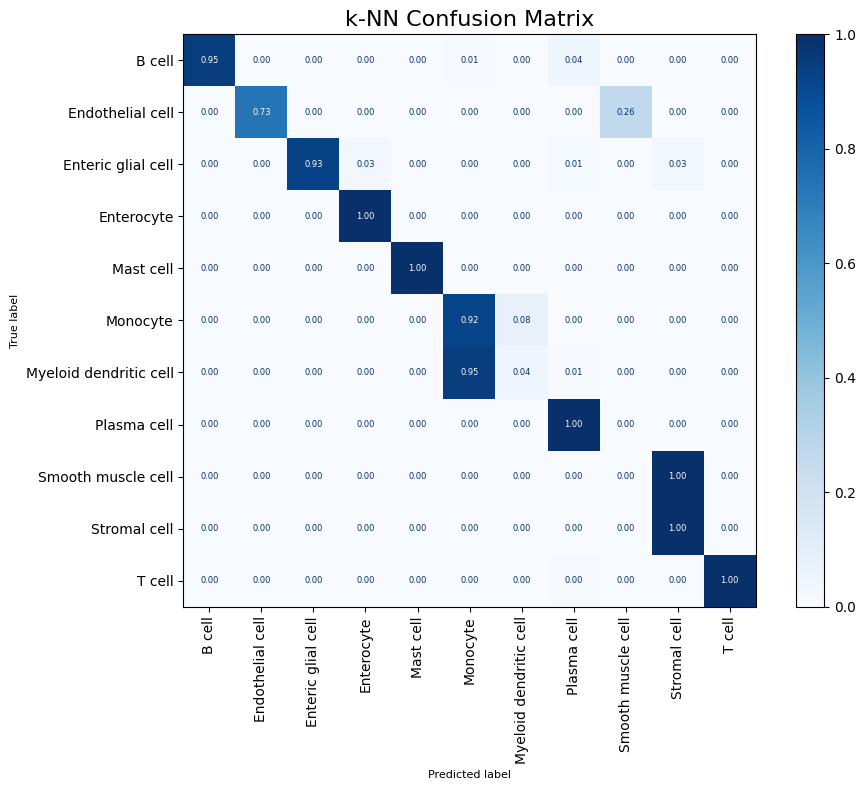

C:\Users\loq\AppData\Local\Temp\ipykernel_19192\2681624449.py:135: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data.obs["y_pred_lr"] = y_pred_lr


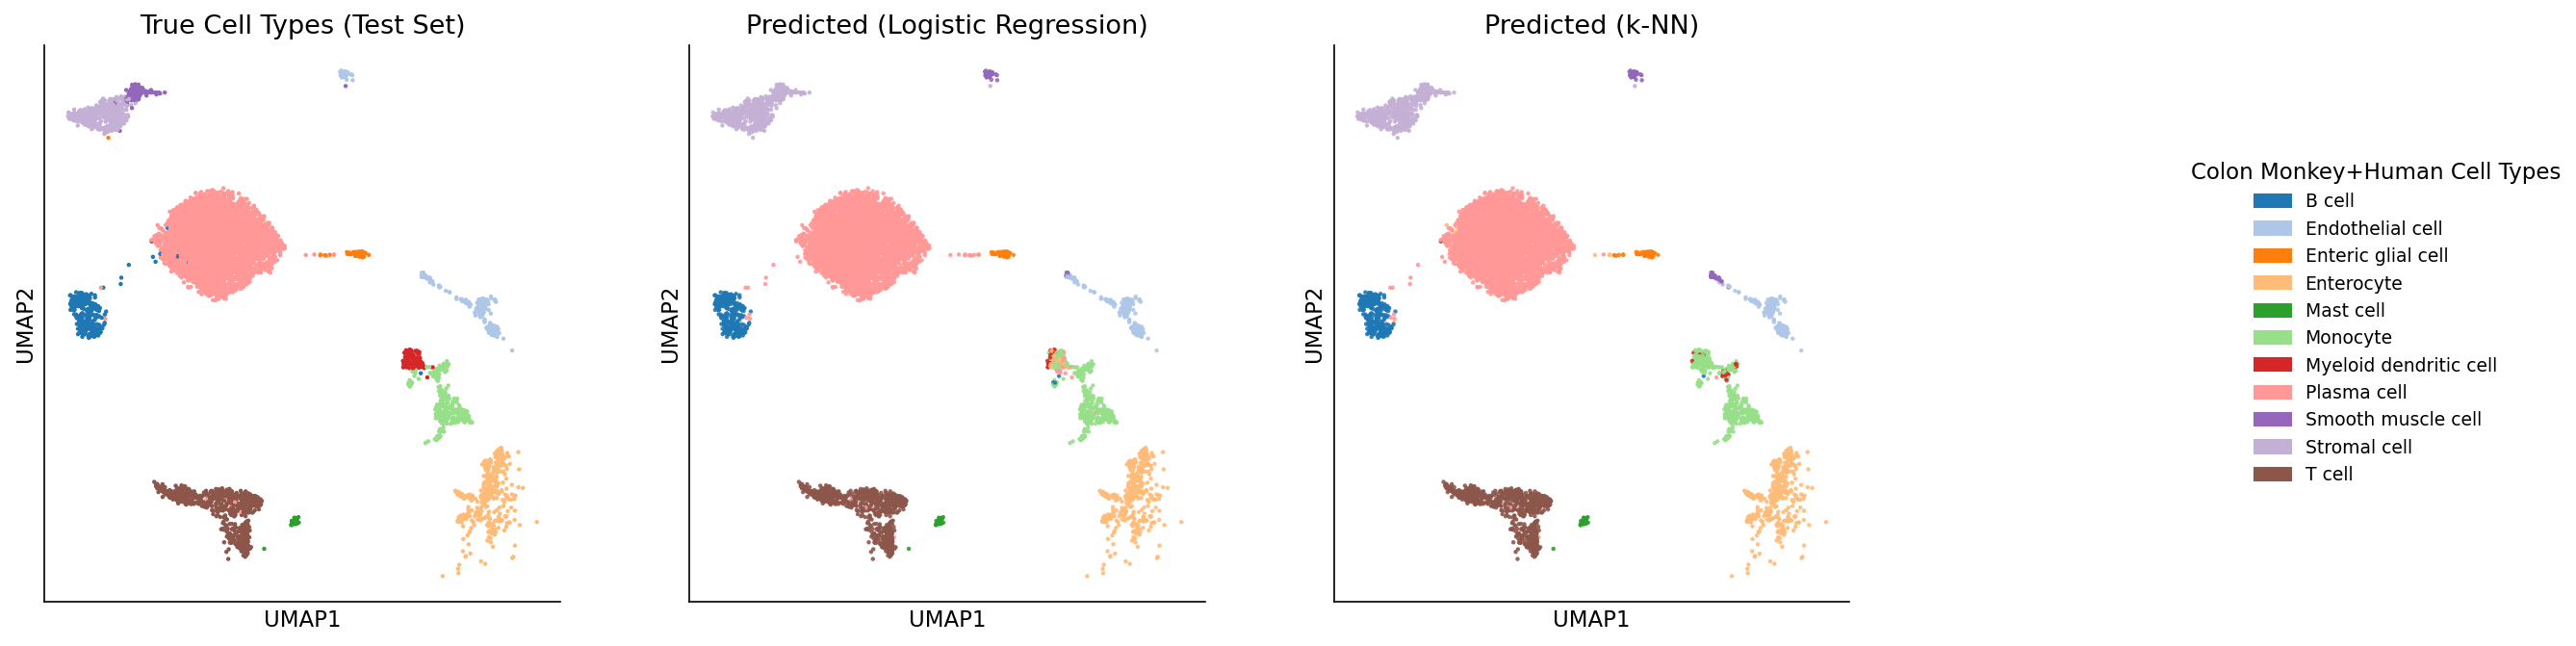

In [ ]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay


sc.pp.neighbors(adata_1, use_rep="X_emb")
sc.tl.umap(adata_1)

ax = sc.pl.umap(
    adata_1,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Colon - Monkey+Human: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()


ax = sc.pl.umap(
    adata_1,
    color='species',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Colon - Monkey+Human: Species"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier 

train_data = adata_1[adata_1.obs["species"] != "monkey"]
test_data  = adata_1[adata_1.obs["species"] == "monkey"]

X_train = train_data.obsm["X_emb"]
X_test  = test_data.obsm["X_emb"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Colon Monkey+Human Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

# Monkey to Human

=== Logistic Regression ===
Accuracy: 0.9503241397828839
                        precision    recall  f1-score   support

                B cell       0.99      0.99      0.99      2069
      Endothelial cell       0.75      0.91      0.82       348
    Enteric glial cell       0.97      1.00      0.98       848
            Enterocyte       1.00      0.99      0.99      5657
             Mast cell       0.98      0.90      0.94       393
              Monocyte       0.94      0.99      0.96       748
Myeloid dendritic cell       0.20      0.03      0.04        40
           Plasma cell       1.00      0.98      0.99      3308
    Smooth muscle cell       0.00      0.01      0.00        82
          Stromal cell       0.98      0.64      0.77      2597
                T cell       0.99      1.00      0.99      9979

              accuracy                           0.95     26069
             macro avg       0.80      0.77      0.77     26069
          weighted avg       0.98      0.95  

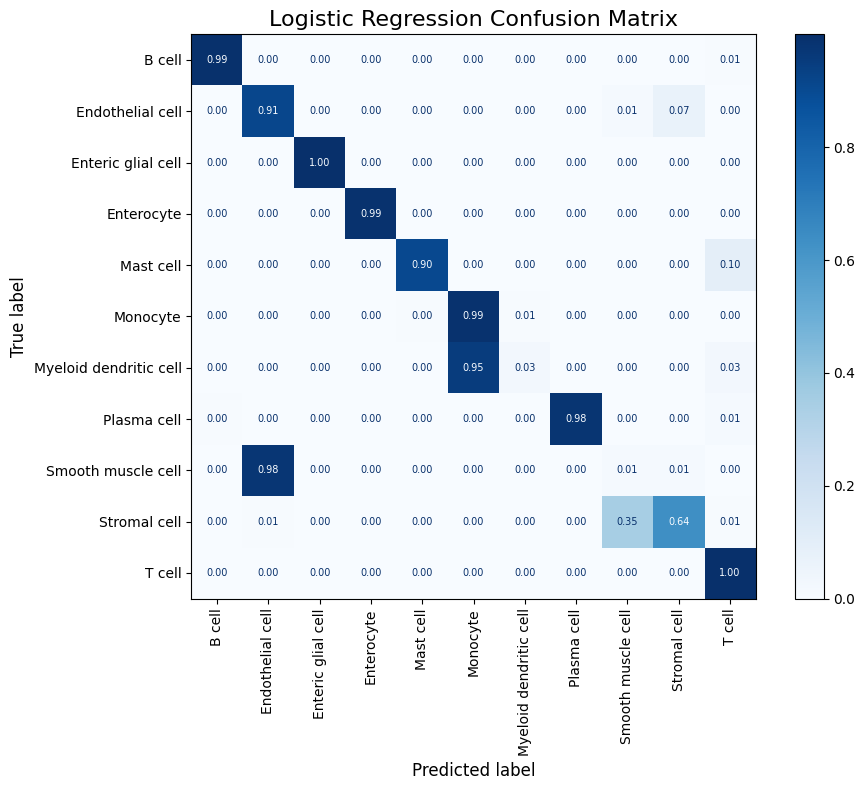


=== k-NN ===
Accuracy: 0.946833403659519
                        precision    recall  f1-score   support

                B cell       0.98      1.00      0.99      2069
      Endothelial cell       0.75      0.91      0.82       348
    Enteric glial cell       0.97      1.00      0.98       848
            Enterocyte       1.00      0.99      0.99      5657
             Mast cell       0.93      0.95      0.94       393
              Monocyte       0.94      0.97      0.95       748
Myeloid dendritic cell       0.25      0.03      0.05        40
           Plasma cell       1.00      0.97      0.98      3308
    Smooth muscle cell       0.00      0.02      0.00        82
          Stromal cell       0.98      0.61      0.75      2597
                T cell       0.99      1.00      1.00      9979

              accuracy                           0.95     26069
             macro avg       0.80      0.77      0.77     26069
          weighted avg       0.98      0.95      0.96     26

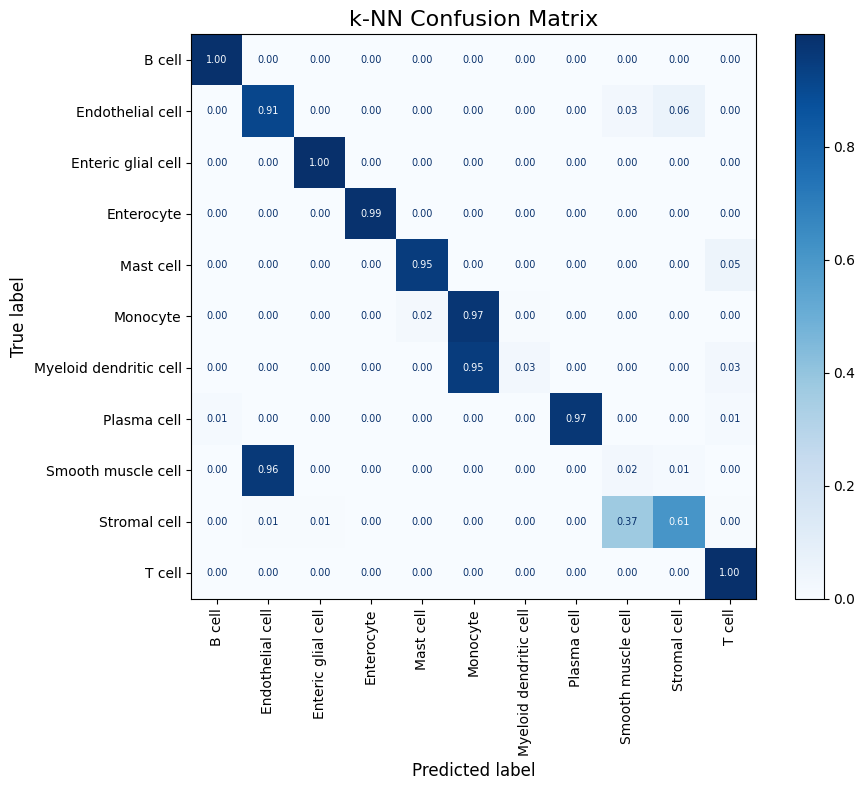

C:\Users\loq\AppData\Local\Temp\ipykernel_19192\1388071340.py:72: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data.obs["y_pred_lr"] = y_pred_lr


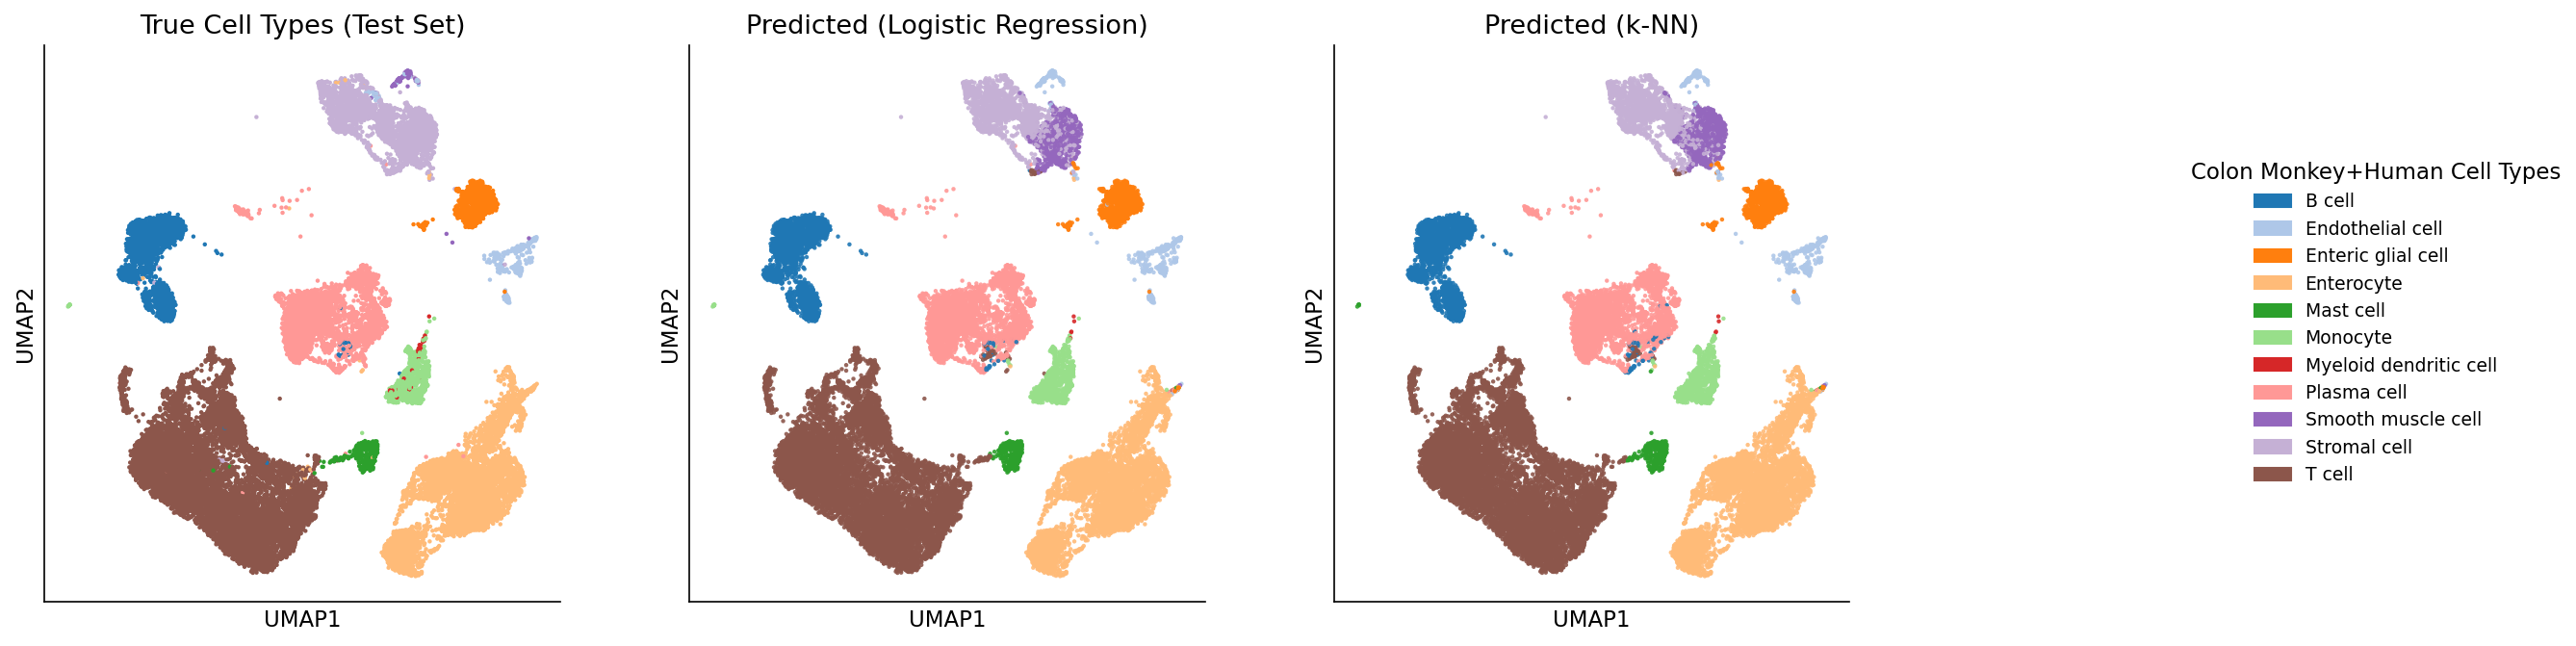

In [18]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay


train_data = adata_1[adata_1.obs["species"] == "monkey"]
test_data  = adata_1[adata_1.obs["species"] != "monkey"]

X_train = train_data.obsm["X_emb"]
X_test  = test_data.obsm["X_emb"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Colon Monkey+Human Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()